Implementation Of Logistic Regression 

In [63]:
#Importing Modules And Libraries
import numpy as np,matplotlib.pyplot as plt
import copy,math
from utils_class import *
from public_tests_class import *
%matplotlib inline


In [64]:
#Loading The Data Set 
#Exam Scores And Admission Decision 
x_train,y_train=load_data("ex2data1.txt")

In [65]:
#Viewing The Variables
print("First 5 Elements In x_train Are:\n",x_train[:5])
print("Type Of x_train:",type(x_train))
print()
print("First 5 Elements In y_train Are:\n",y_train[:5])
print("Type Of y_train:",type(y_train))
#Dimensions Of Variables
print("Shape (x_train):"+str(x_train.shape))
print("Shape (y_train):"+str(y_train.shape))
print("Number Of Training Examples:%d"%(len(y_train)))


First 5 Elements In x_train Are:
 [[34.62365962 78.02469282]
 [30.28671077 43.89499752]
 [35.84740877 72.90219803]
 [60.18259939 86.3085521 ]
 [79.03273605 75.34437644]]
Type Of x_train: <class 'numpy.ndarray'>

First 5 Elements In y_train Are:
 [0. 0. 0. 1. 1.]
Type Of y_train: <class 'numpy.ndarray'>
Shape (x_train):(100, 2)
Shape (y_train):(100,)
Number Of Training Examples:100


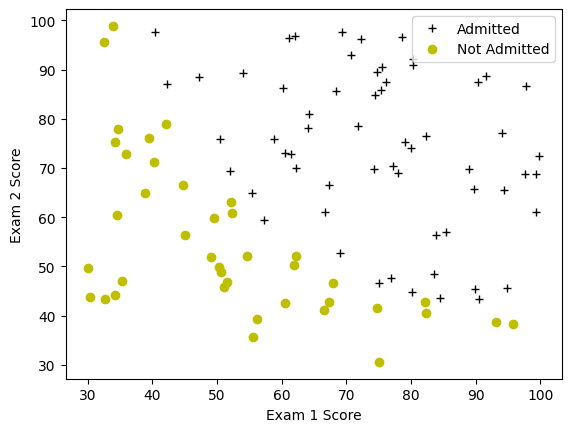

In [66]:
#Plotting The Data
plot_data(x_train,y_train[:],pos_label="Admitted",neg_label="Not Admitted")
#Setting The x&y-Axes Labels
plt.ylabel('Exam 2 Score')
plt.xlabel('Exam 1 Score')
plt.legend(loc='upper right')
plt.show()

In [67]:
#Sigmoid Function
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [68]:
#Implementing Loss Function
def loss(x,y,w,b,lambda_=1):
    m,n=x.shape
    cost=0
    for i in range(m):
        z=np.dot(x[i],w)+b
        f=sigmoid(z)
        cost+=-y[i]*np.log(f)-(1-y[i])*np.log(1-f)
    total=cost/m
    return total

In [69]:
#Gradient For Logistic Regression
def grad(x,y,w,b,lambda_=None):
    m,n=x.shape
    dj_dw=np.zeros(w.shape)
    dj_db=0.
    for i in range(m):
        f=sigmoid(np.dot(x[i],w)+b)
        err=f-y[i]
        for j in range(n):
            dj_dw[j]+=(err*x[i,j])
        dj_db+=err
    dj_dw/=m
    dj_db/=m
    return dj_db,dj_dw

In [70]:
#Testing The Gradient With Non-Zero w
test_w=np.array([0.2,-0.5])
test_b=-24
db,dw=grad(x_train,y_train,test_w,test_b)
print("dj_db At test_w",db)
print("dj_dw At test_w:",dw.tolist())
#UNIT TESTS
compute_gradient_test(grad)

dj_db At test_w -0.5999999999991071
dj_dw At test_w: [-44.831353617873795, -44.37384124953978]
All tests passed!


In [71]:
#Implementing Gradient Descent
def grad_descent(x,y,w_in,b_in,loss,grad,alpha,iters,lambda_):
    m=len(x)
    j_arr=[]
    w_arr=[]
    for i in range(iters):
        db,dw=grad(x,y,w_in,b_in,lambda_)
        w_in-=(alpha*dw)
        b_in-=(alpha*db)
        if i<100000:
            cost=loss(x,y,w_in,b_in,lambda_)
            j_arr.append(cost)
        if i%math.ceil(iters/10)==0 or i==(iters-1):
            w_arr.append(w_in)
            print(f"Iteration {i:4}-->Cost{float(j_arr[-1]):8.2f} ")
    return w_in,b_in,j_arr,w_arr


In [72]:
#Testing The Implementation
np.random.seed(1)
initial_w=0.01*(np.random.rand(2).reshape(-1,1)-0.5)
initial_b=-8
iters=10000
alpha=0.001
w,b,j_arr,_=grad_descent(x_train,y_train,initial_w,initial_b,loss,grad,alpha,iters,0)


Iteration    0-->Cost    0.96 


C:\Users\TRAGI\AppData\Local\Temp\ipykernel_18500\1136734887.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Iteration {i:4}-->Cost{float(j_arr[-1]):8.2f} ")


Iteration 1000-->Cost    0.31 
Iteration 2000-->Cost    0.30 
Iteration 3000-->Cost    0.30 
Iteration 4000-->Cost    0.30 
Iteration 5000-->Cost    0.30 
Iteration 6000-->Cost    0.30 
Iteration 7000-->Cost    0.30 
Iteration 8000-->Cost    0.30 
Iteration 9000-->Cost    0.30 
Iteration 9999-->Cost    0.30 


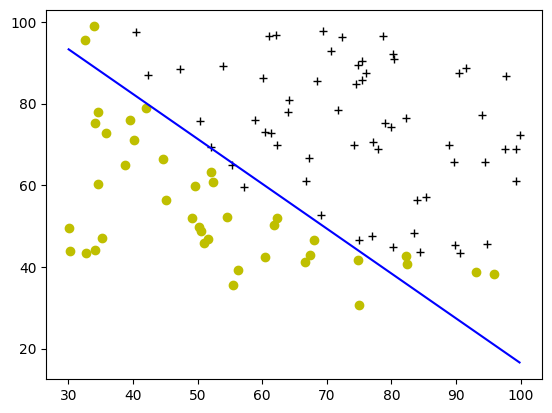

In [73]:
#Plotting The Decision Boundary
plot_decision_boundary(w,b,x_train,y_train)

In [74]:
#Evaluating The Logistic Regression
def predict(x,w,b):
    m,n=x.shape
    p=np.zeros(m)
    for i in range(m):
        z=np.dot(x[i],w)
        z+=b
        f=sigmoid(z)
        #Applying Threshold
        p[i]=1 if f>0.5 else 0
    return p

In [75]:
#Testing The Prediction
np.random.seed(1)
temp_w=np.random.rand(2)
temp_b=0.3
temp_x=np.random.randn(4,2)-0.5
temp_pred=predict(temp_x,temp_w,temp_b)
print(f'Output Of Prediction-> Shape{temp_pred.shape},Value{temp_pred}')
#UNIT TESTS
predict_test(predict)

Output Of Prediction-> Shape(4,),Value[0. 0. 0. 0.]
All tests passed!


In [76]:
#Computing The Accuracy On Training Set
p=predict(x_train,w,b)
print('Train Accuracy:%f'%(np.mean(p==y_train)*100))

Train Accuracy:92.000000


Regularized Logistic Regression

In [77]:
#Loading The Data Set
x_train,y_train=load_data("ex2data2.txt")
print("x_train:",x_train[:5])
print("Type Of x_train:",type(x_train))
print("y_train:",y_train[:5])
print("Type Of y_train:",type(y_train))
print('Shape (x_train):'+str(x_train.shape))
print('Shape (y_train)'+str(y_train.shape))
print('Number Of Training Example %d'%(len(y_train)))

x_train: [[ 0.051267  0.69956 ]
 [-0.092742  0.68494 ]
 [-0.21371   0.69225 ]
 [-0.375     0.50219 ]
 [-0.51325   0.46564 ]]
Type Of x_train: <class 'numpy.ndarray'>
y_train: [1. 1. 1. 1. 1.]
Type Of y_train: <class 'numpy.ndarray'>
Shape (x_train):(118, 2)
Shape (y_train)(118,)
Number Of Training Example 118


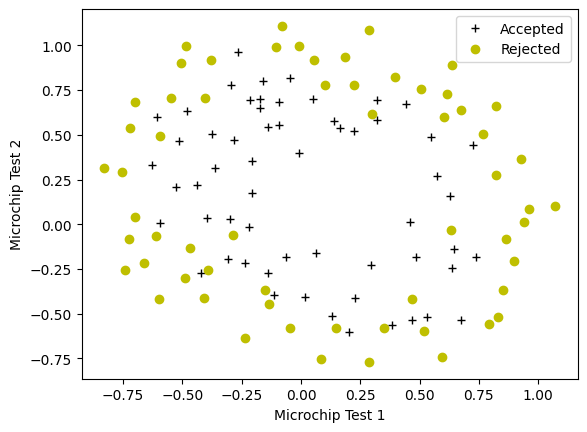

In [78]:
#Plotting The Data
plot_data(x_train,y_train[:],pos_label="Accepted",neg_label="Rejected")
plt.ylabel('Microchip Test 2')
plt.xlabel('Microchip Test 1')
plt.legend(loc='upper right')
plt.show()

In [79]:
#Feature Mapping
print("Original Shape Of Data:",x_train.shape)
mapx=map_feature(x_train[:,0],x_train[:,1])
print("Shape After Feature Mapping:",mapx.shape)
print()
print("x_train[0]",x_train[0])
print("Mapped x_train[0]",mapx[0])

Original Shape Of Data: (118, 2)
Shape After Feature Mapping: (118, 27)

x_train[0] [0.051267 0.69956 ]
Mapped x_train[0] [5.12670000e-02 6.99560000e-01 2.62830529e-03 3.58643425e-02
 4.89384194e-01 1.34745327e-04 1.83865725e-03 2.50892595e-02
 3.42353606e-01 6.90798869e-06 9.42624411e-05 1.28625106e-03
 1.75514423e-02 2.39496889e-01 3.54151856e-07 4.83255257e-06
 6.59422333e-05 8.99809795e-04 1.22782870e-02 1.67542444e-01
 1.81563032e-08 2.47750473e-07 3.38066048e-06 4.61305487e-05
 6.29470940e-04 8.58939846e-03 1.17205992e-01]


In [80]:
#Loss Function For Regularized Logistic Regression
def reg_loss(x,y,w,b,lambda_=1):
    m,n=x.shape
    reg=0.
    l=sum(np.square(w))
    total=loss(x,y,w,b)+((lambda_/(2*m))*reg)
    return total

In [81]:
#Gradient For Regularized Logistic Regression
def grad_reg(x,y,w,b,lambda_=1):
    m,n=x.shape
    db,dw=grad(x,y,w,b)
    for i in range(n):
        dw[i]+=((lambda_/m)*w[i])
    return db,dw

In [82]:
#Gradient Decent 
np.random.seed(1)
initial_w=np.random.rand(mapx.shape[1])-0.5
initial_b=1.
lambda_=0.01;                                          
iters=10000
alpha=0.01
w,b,j_arr,_ =grad_descent(mapx,y_train, initial_w,initial_b, 
                                    reg_loss,grad_reg,alpha,iters,lambda_)

Iteration    0-->Cost    0.72 
Iteration 1000-->Cost    0.59 
Iteration 2000-->Cost    0.56 
Iteration 3000-->Cost    0.53 
Iteration 4000-->Cost    0.51 
Iteration 5000-->Cost    0.50 
Iteration 6000-->Cost    0.48 
Iteration 7000-->Cost    0.47 
Iteration 8000-->Cost    0.46 
Iteration 9000-->Cost    0.45 
Iteration 9999-->Cost    0.44 


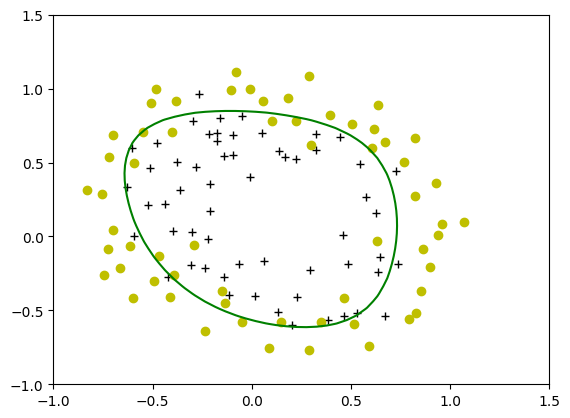

In [83]:
#Plotting The Decision Boundary
plot_decision_boundary(w,b,mapx,y_train)

In [86]:
#Evaluating Regularized Logistic Regression
pred=predict(mapx,w,b)
print('Model Accuracy:%f' %(np.mean(pred==y_train)*100))

Model Accuracy:82.203390
